# 多通道去耦合測試 - 使用標籤影像評估

此 notebook 使用標籤影像來定量評估不同參數的效果

## 評估指標
1. **背景標準差**（標籤外區域）：越低表示背景越均勻
2. **前景標準差**（標籤內區域）：越低表示神經纖維信號越一致

## 1. 導入必要的套件

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from PIL import Image

# 添加專案路徑
project_root = Path().absolute().parent.parent
sys.path.insert(0, str(project_root))

# 導入處理模組
from preprocessing.channel_decoupling import ChannelDecoupler
from preprocessing.config import ChannelDecouplingConfig
from preprocessing.image_loader import ImageLoader

# 設定 matplotlib 中文顯示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 套件導入完成")

✓ 套件導入完成


## 2. 載入影像和標籤

In [2]:
# 設定路徑
IMAGE_PATH = "/Users/ponywen/projects/ienf_q/data/Original/S163-2_a.tif"  # 請修改此路徑
LABEL_PATH = IMAGE_PATH.replace("Original", "Label")

# 載入影像
loader = ImageLoader()
image_data = loader.load(IMAGE_PATH)

# 載入標籤
label_image = Image.open(LABEL_PATH).convert("L")
label_data = np.array(label_image)

# 創建布林遮罩（標籤內=True, 標籤外=False）
label_mask = label_data > 0

print(f"影像尺寸: {image_data.shape}")
print(f"標籤尺寸: {label_data.shape}")
print(f"標籤內像素數: {label_mask.sum()} ({label_mask.sum()/label_mask.size*100:.2f}%)")
print(f"標籤外像素數: {(~label_mask).sum()} ({(~label_mask).sum()/label_mask.size*100:.2f}%)")

✓ 載入圖像: S163-2_a.tif
  - 尺寸: (1028, 4713, 3)
  - 類型: uint8
  - 範圍: [0, 255]
影像尺寸: (1028, 4713, 3)
標籤尺寸: (1028, 4713)
標籤內像素數: 4390 (0.09%)
標籤外像素數: 4840574 (99.91%)


## 3. 顯示影像和標籤

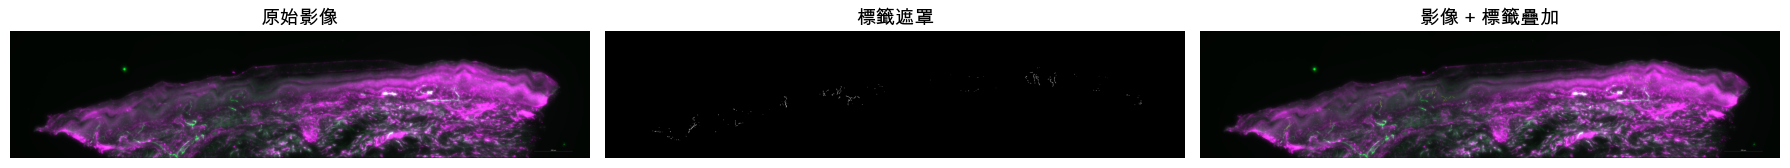

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 原始影像
axes[0].imshow(image_data)
axes[0].set_title('原始影像', fontsize=14)
axes[0].axis('off')

# 標籤
axes[1].imshow(label_mask, cmap='gray')
axes[1].set_title('標籤遮罩', fontsize=14)
axes[1].axis('off')

# 疊加顯示
overlay = image_data.copy()
if len(overlay.shape) == 2:
    overlay = np.stack([overlay]*3, axis=-1)
overlay[label_mask] = overlay[label_mask] * 0.7 + np.array([255, 255, 0]) * 0.3  # 黃色疊加
axes[2].imshow(overlay.astype(np.uint8))
axes[2].set_title('影像 + 標籤疊加', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 4. 分離通道

In [4]:
# 分離 RGB 通道
if len(image_data.shape) == 3 and image_data.shape[2] >= 3:
    red_channel = image_data[:, :, 0]
    green_channel = image_data[:, :, 1]
    blue_channel = image_data[:, :, 2]
else:
    raise ValueError(f"需要 RGB 影像，收到 {image_data.shape}")

print(f"紅色通道 - 範圍: [{red_channel.min()}, {red_channel.max()}]")
print(f"綠色通道 - 範圍: [{green_channel.min()}, {green_channel.max()}]")
print(f"藍色通道 - 範圍: [{blue_channel.min()}, {blue_channel.max()}]")

紅色通道 - 範圍: [0, 254]
綠色通道 - 範圍: [0, 254]
藍色通道 - 範圍: [0, 255]


## 5. 網格搜索 + 標準差計算

對每組 (α, β) 參數，計算：
- 背景標準差（標籤外）
- 前景標準差（標籤內）
- 總體標準差

In [5]:
# 定義參數範圍
alpha_values = np.linspace(0.0, 0.5, 11)  # 0.0, 0.05, 0.1, ..., 0.5
beta_values = np.linspace(0.0, 0.5, 11)

# 儲存結果
results = []

print(f"開始網格搜索: {len(alpha_values)} × {len(beta_values)} = {len(alpha_values) * len(beta_values)} 組參數\n")

# 進度計數
total = len(alpha_values) * len(beta_values)
count = 0

for alpha in alpha_values:
    for beta in beta_values:
        count += 1
        
        # 配置
        config = ChannelDecouplingConfig(
            alpha=alpha,
            beta=beta,
            use_blue_channel=(beta > 0)
        )
        
        # 應用去耦合
        decoupler = ChannelDecoupler(config)
        if beta > 0:
            corrected = decoupler.process(green_channel, red_channel, blue_channel)
        else:
            corrected = decoupler.process(green_channel, red_channel)
        
        # 計算標準差
        background_std = np.std(corrected[~label_mask])  # 標籤外
        foreground_std = np.std(corrected[label_mask])   # 標籤內
        overall_std = np.std(corrected)                  # 整體
        
        # 計算平均值
        background_mean = np.mean(corrected[~label_mask])
        foreground_mean = np.mean(corrected[label_mask])
        
        # 儲存結果
        results.append({
            'alpha': alpha,
            'beta': beta,
            'background_std': background_std,
            'foreground_std': foreground_std,
            'overall_std': overall_std,
            'background_mean': background_mean,
            'foreground_mean': foreground_mean,
            'combined_score': background_std + foreground_std  # 簡單的組合得分
        })
        
        # 顯示進度
        if count % 10 == 0 or count == total:
            print(f"進度: {count}/{total} ({count/total*100:.1f}%) - "
                  f"α={alpha:.2f}, β={beta:.2f} → "
                  f"背景std={background_std:.2f}, 前景std={foreground_std:.2f}")

# 轉換為 DataFrame
df_results = pd.DataFrame(results)

print(f"\n✓ 網格搜索完成！")

開始網格搜索: 11 × 11 = 121 組參數

進度: 10/121 (8.3%) - α=0.00, β=0.45 → 背景std=10.69, 前景std=26.63
進度: 20/121 (16.5%) - α=0.05, β=0.40 → 背景std=10.84, 前景std=26.93
進度: 30/121 (24.8%) - α=0.10, β=0.35 → 背景std=10.99, 前景std=27.23
進度: 40/121 (33.1%) - α=0.15, β=0.30 → 背景std=11.15, 前景std=27.52
進度: 50/121 (41.3%) - α=0.20, β=0.25 → 背景std=11.31, 前景std=27.81
進度: 60/121 (49.6%) - α=0.25, β=0.20 → 背景std=11.44, 前景std=28.11
進度: 70/121 (57.9%) - α=0.30, β=0.15 → 背景std=11.59, 前景std=28.39
進度: 80/121 (66.1%) - α=0.35, β=0.10 → 背景std=11.72, 前景std=28.69
進度: 90/121 (74.4%) - α=0.40, β=0.05 → 背景std=11.88, 前景std=28.98
進度: 100/121 (82.6%) - α=0.45, β=0.00 → 背景std=12.04, 前景std=29.27
進度: 110/121 (90.9%) - α=0.45, β=0.50 → 背景std=4.50, 前景std=15.59
進度: 120/121 (99.2%) - α=0.50, β=0.45 → 背景std=4.57, 前景std=15.87
進度: 121/121 (100.0%) - α=0.50, β=0.50 → 背景std=4.27, 前景std=14.71

✓ 網格搜索完成！


## 6. 查看結果統計表

In [6]:
# 顯示前 20 個最佳結果（依背景標準差排序）
print("\n===== 背景標準差最低的 20 組參數 =====")
print(df_results.nsmallest(20, 'background_std')[[
    'alpha', 'beta', 'background_std', 'foreground_std', 'combined_score'
]])

print("\n===== 前景標準差最低的 20 組參數 =====")
print(df_results.nsmallest(20, 'foreground_std')[[
    'alpha', 'beta', 'background_std', 'foreground_std', 'combined_score'
]])

print("\n===== 組合得分最低的 20 組參數 =====")
print(df_results.nsmallest(20, 'combined_score')[[
    'alpha', 'beta', 'background_std', 'foreground_std', 'combined_score'
]])


===== 背景標準差最低的 20 組參數 =====
     alpha  beta  background_std  foreground_std  combined_score
120   0.50  0.50        4.269178       14.708807       18.977986
109   0.45  0.50        4.495033       15.592910       20.087943
119   0.50  0.45        4.570139       15.868651       20.438789
98    0.40  0.50        4.791080       16.581200       21.372280
108   0.45  0.45        4.868087       16.861981       21.730068
118   0.50  0.40        4.964013       17.171815       22.135827
87    0.35  0.50        5.145763       17.586592       22.732355
97    0.40  0.45        5.245522       17.887694       23.133216
107   0.45  0.40        5.337312       18.182511       23.519823
117   0.50  0.35        5.427377       18.472528       23.899905
76    0.30  0.50        5.576120       18.648159       24.224279
86    0.35  0.45        5.669509       18.928504       24.598014
96    0.40  0.40        5.781233       19.246963       25.028196
106   0.45  0.35        5.876773       19.532679       25.409

## 7. 視覺化：熱力圖

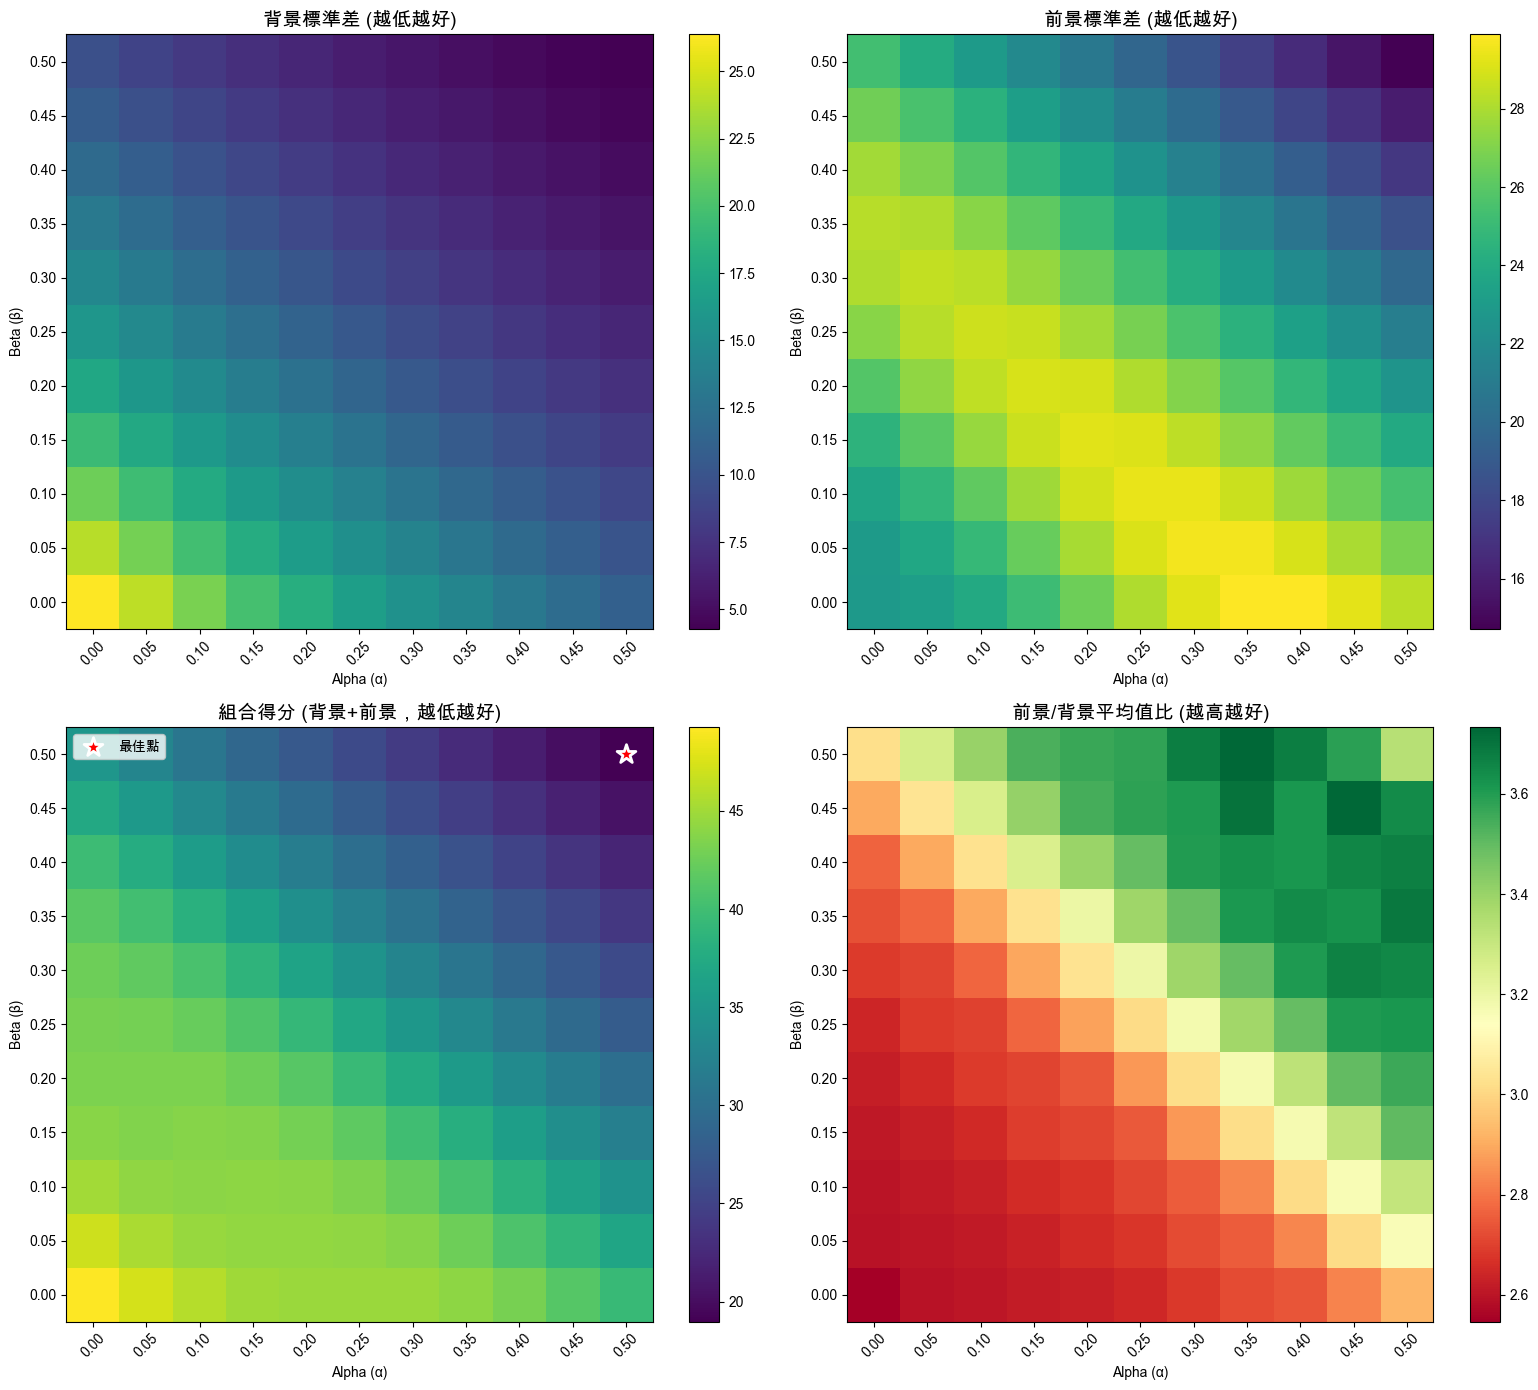


推薦的最佳參數（組合得分最低）:
  Alpha = 0.500
  Beta = 0.500
  背景標準差 = 4.27
  前景標準差 = 14.71
  組合得分 = 18.98


In [7]:
# 創建熱力圖數據
def create_heatmap_data(df, metric):
    """創建熱力圖數據矩陣"""
    pivot = df.pivot(index='beta', columns='alpha', values=metric)
    return pivot

# 創建四個熱力圖
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. 背景標準差
heatmap_bg = create_heatmap_data(df_results, 'background_std')
im1 = axes[0, 0].imshow(heatmap_bg, cmap='viridis', aspect='auto', origin='lower')
axes[0, 0].set_title('背景標準差 (越低越好)', fontsize=14)
axes[0, 0].set_xlabel('Alpha (α)')
axes[0, 0].set_ylabel('Beta (β)')
axes[0, 0].set_xticks(range(len(alpha_values)))
axes[0, 0].set_yticks(range(len(beta_values)))
axes[0, 0].set_xticklabels([f'{a:.2f}' for a in alpha_values], rotation=45)
axes[0, 0].set_yticklabels([f'{b:.2f}' for b in beta_values])
plt.colorbar(im1, ax=axes[0, 0])

# 2. 前景標準差
heatmap_fg = create_heatmap_data(df_results, 'foreground_std')
im2 = axes[0, 1].imshow(heatmap_fg, cmap='viridis', aspect='auto', origin='lower')
axes[0, 1].set_title('前景標準差 (越低越好)', fontsize=14)
axes[0, 1].set_xlabel('Alpha (α)')
axes[0, 1].set_ylabel('Beta (β)')
axes[0, 1].set_xticks(range(len(alpha_values)))
axes[0, 1].set_yticks(range(len(beta_values)))
axes[0, 1].set_xticklabels([f'{a:.2f}' for a in alpha_values], rotation=45)
axes[0, 1].set_yticklabels([f'{b:.2f}' for b in beta_values])
plt.colorbar(im2, ax=axes[0, 1])

# 3. 組合得分
heatmap_combined = create_heatmap_data(df_results, 'combined_score')
im3 = axes[1, 0].imshow(heatmap_combined, cmap='viridis', aspect='auto', origin='lower')
axes[1, 0].set_title('組合得分 (背景+前景，越低越好)', fontsize=14)
axes[1, 0].set_xlabel('Alpha (α)')
axes[1, 0].set_ylabel('Beta (β)')
axes[1, 0].set_xticks(range(len(alpha_values)))
axes[1, 0].set_yticks(range(len(beta_values)))
axes[1, 0].set_xticklabels([f'{a:.2f}' for a in alpha_values], rotation=45)
axes[1, 0].set_yticklabels([f'{b:.2f}' for b in beta_values])
plt.colorbar(im3, ax=axes[1, 0])

# 標記最佳點
best_idx = df_results['combined_score'].idxmin()
best_row = df_results.iloc[best_idx]
best_alpha_idx = list(alpha_values).index(min(alpha_values, key=lambda x: abs(x - best_row['alpha'])))
best_beta_idx = list(beta_values).index(min(beta_values, key=lambda x: abs(x - best_row['beta'])))
axes[1, 0].scatter([best_alpha_idx], [best_beta_idx], color='red', s=200, marker='*', 
                   edgecolors='white', linewidths=2, label='最佳點', zorder=5)
axes[1, 0].legend()

# 4. 前景/背景比值
df_results['fg_bg_ratio'] = df_results['foreground_mean'] / (df_results['background_mean'] + 1e-10)
heatmap_ratio = create_heatmap_data(df_results, 'fg_bg_ratio')
im4 = axes[1, 1].imshow(heatmap_ratio, cmap='RdYlGn', aspect='auto', origin='lower')
axes[1, 1].set_title('前景/背景平均值比 (越高越好)', fontsize=14)
axes[1, 1].set_xlabel('Alpha (α)')
axes[1, 1].set_ylabel('Beta (β)')
axes[1, 1].set_xticks(range(len(alpha_values)))
axes[1, 1].set_yticks(range(len(beta_values)))
axes[1, 1].set_xticklabels([f'{a:.2f}' for a in alpha_values], rotation=45)
axes[1, 1].set_yticklabels([f'{b:.2f}' for b in beta_values])
plt.colorbar(im4, ax=axes[1, 1])

plt.tight_layout()
plt.show()

print(f"\n推薦的最佳參數（組合得分最低）:")
print(f"  Alpha = {best_row['alpha']:.3f}")
print(f"  Beta = {best_row['beta']:.3f}")
print(f"  背景標準差 = {best_row['background_std']:.2f}")
print(f"  前景標準差 = {best_row['foreground_std']:.2f}")
print(f"  組合得分 = {best_row['combined_score']:.2f}")

## 8. 視覺化：參數-性能曲線

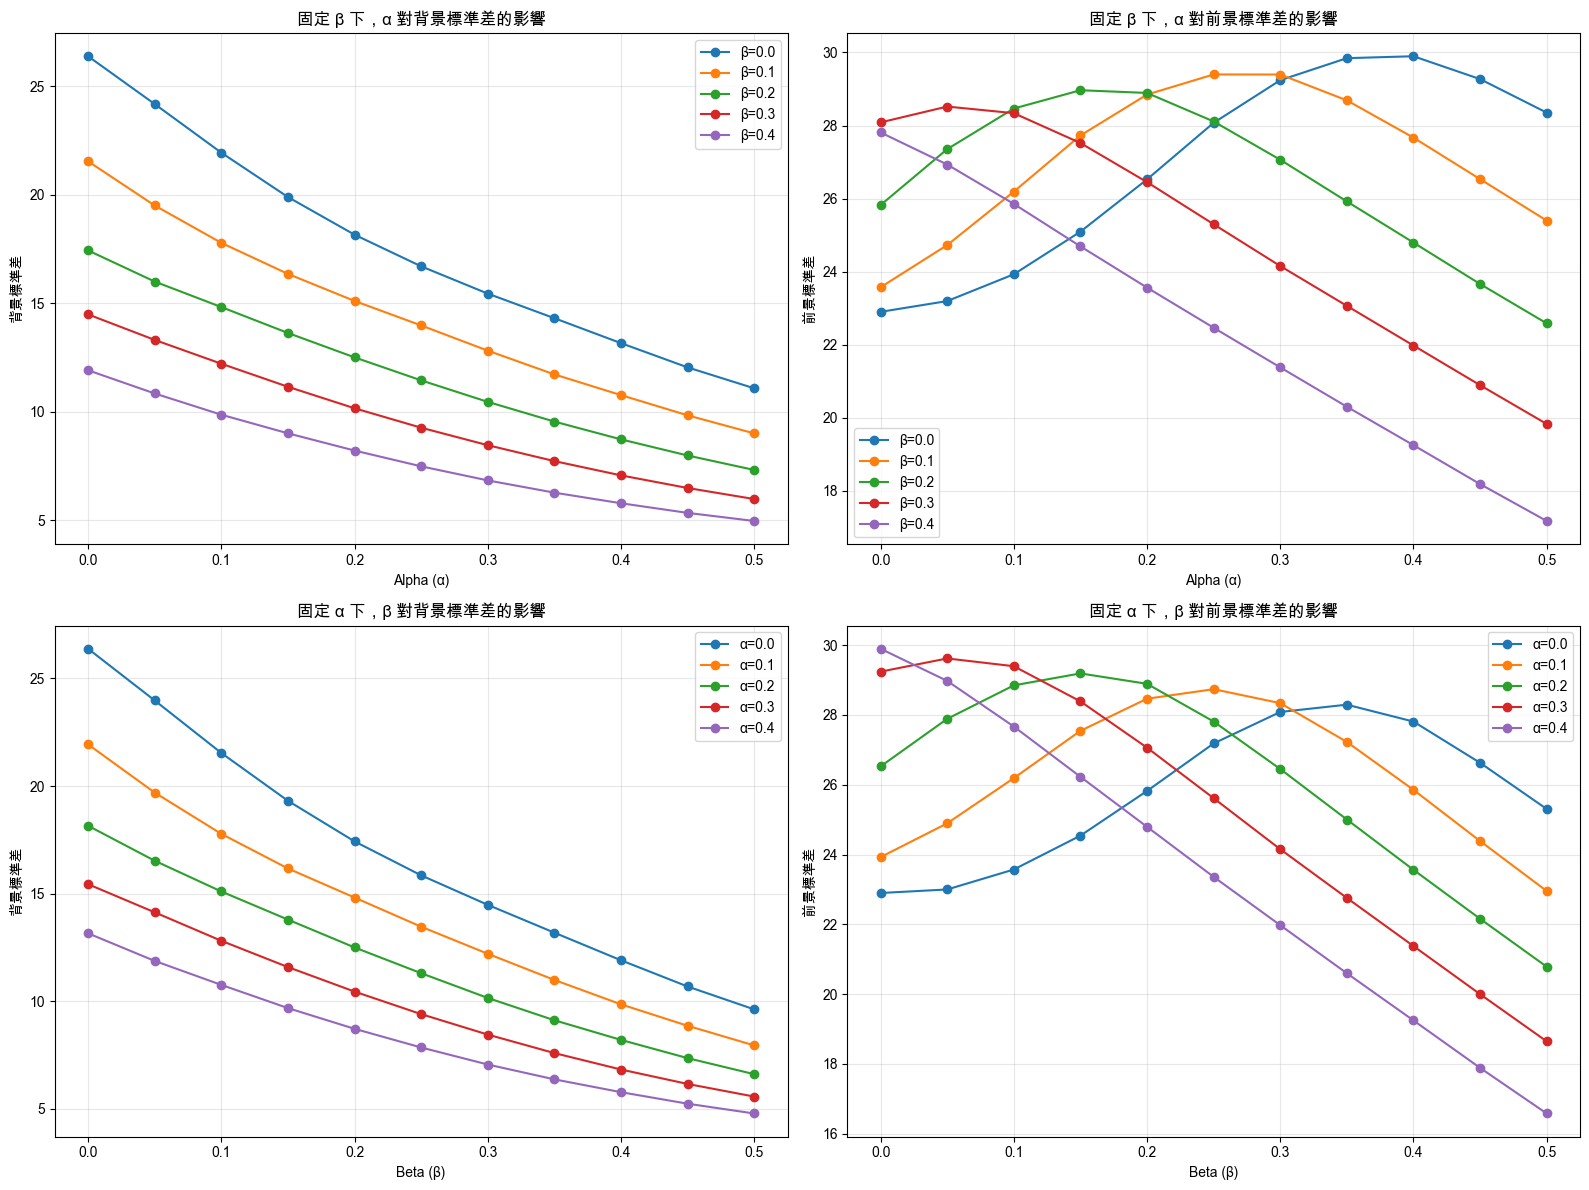

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 固定 beta，看 alpha 的影響
for beta_fixed in [0.0, 0.1, 0.2, 0.3, 0.4]:
    subset = df_results[np.isclose(df_results['beta'], beta_fixed, atol=0.01)]
    axes[0, 0].plot(subset['alpha'], subset['background_std'], 
                   marker='o', label=f'β={beta_fixed:.1f}')
axes[0, 0].set_xlabel('Alpha (α)')
axes[0, 0].set_ylabel('背景標準差')
axes[0, 0].set_title('固定 β 下，α 對背景標準差的影響')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 固定 beta，看 alpha 對前景的影響
for beta_fixed in [0.0, 0.1, 0.2, 0.3, 0.4]:
    subset = df_results[np.isclose(df_results['beta'], beta_fixed, atol=0.01)]
    axes[0, 1].plot(subset['alpha'], subset['foreground_std'], 
                   marker='o', label=f'β={beta_fixed:.1f}')
axes[0, 1].set_xlabel('Alpha (α)')
axes[0, 1].set_ylabel('前景標準差')
axes[0, 1].set_title('固定 β 下，α 對前景標準差的影響')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 固定 alpha，看 beta 的影響
for alpha_fixed in [0.0, 0.1, 0.2, 0.3, 0.4]:
    subset = df_results[np.isclose(df_results['alpha'], alpha_fixed, atol=0.01)]
    axes[1, 0].plot(subset['beta'], subset['background_std'], 
                   marker='o', label=f'α={alpha_fixed:.1f}')
axes[1, 0].set_xlabel('Beta (β)')
axes[1, 0].set_ylabel('背景標準差')
axes[1, 0].set_title('固定 α 下，β 對背景標準差的影響')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 固定 alpha，看 beta 對前景的影響
for alpha_fixed in [0.0, 0.1, 0.2, 0.3, 0.4]:
    subset = df_results[np.isclose(df_results['alpha'], alpha_fixed, atol=0.01)]
    axes[1, 1].plot(subset['beta'], subset['foreground_std'], 
                   marker='o', label=f'α={alpha_fixed:.1f}')
axes[1, 1].set_xlabel('Beta (β)')
axes[1, 1].set_ylabel('前景標準差')
axes[1, 1].set_title('固定 α 下，β 對前景標準差的影響')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. 比較視覺化：最佳參數 vs 原始

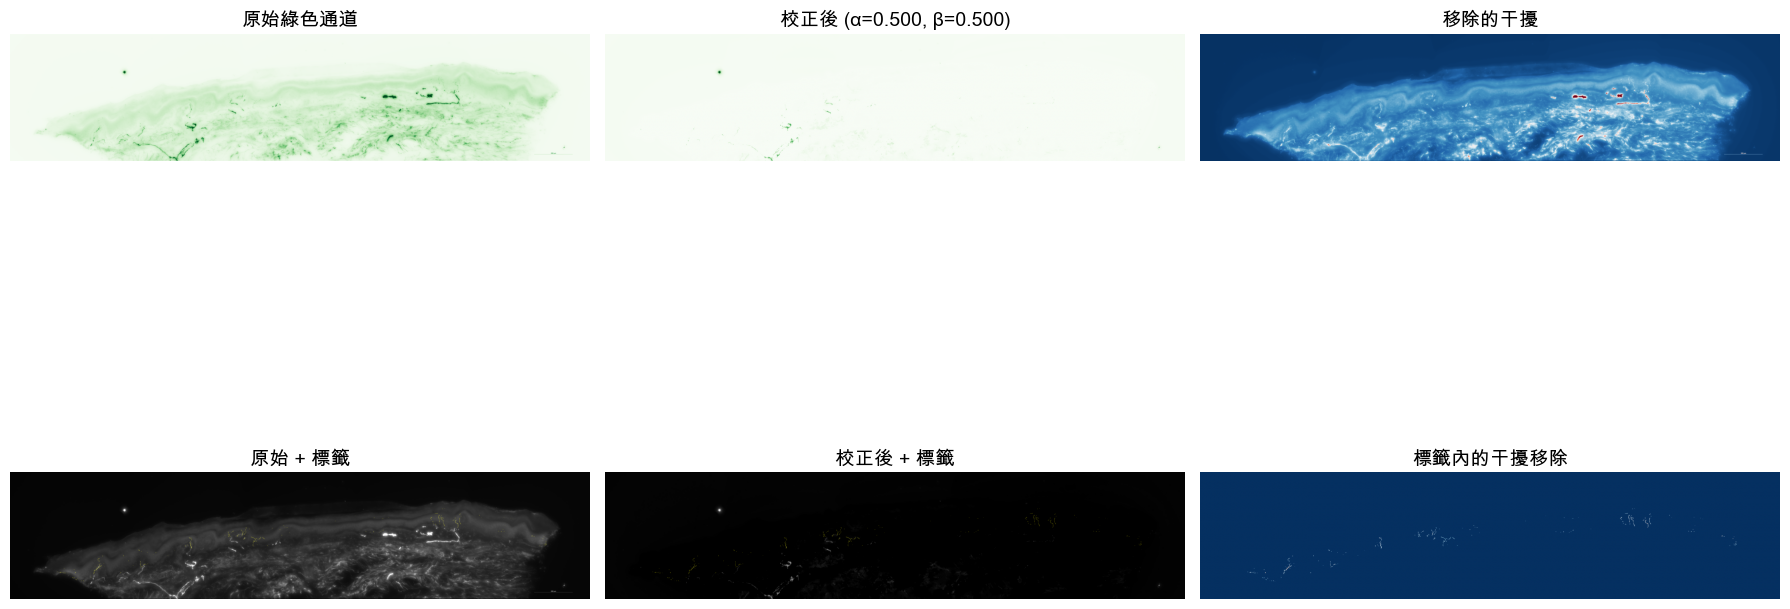


===== 校正前後比較 =====

原始綠色通道:
  背景標準差: 26.37
  前景標準差: 22.90
  背景平均值: 29.95
  前景平均值: 76.27

校正後:
  背景標準差: 4.27 (↓83.8%)
  前景標準差: 14.71 (↓35.8%)
  背景平均值: 1.66
  前景平均值: 5.56


In [9]:
# 使用最佳參數進行校正
best_config = ChannelDecouplingConfig(
    alpha=best_row['alpha'],
    beta=best_row['beta'],
    use_blue_channel=True
)

best_decoupler = ChannelDecoupler(best_config)
best_corrected = best_decoupler.process(green_channel, red_channel, blue_channel)

# 視覺化比較
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 第一行：原始和校正後
axes[0, 0].imshow(green_channel, cmap='Greens')
axes[0, 0].set_title('原始綠色通道', fontsize=14)
axes[0, 0].axis('off')

axes[0, 1].imshow(best_corrected, cmap='Greens')
axes[0, 1].set_title(f'校正後 (α={best_row["alpha"]:.3f}, β={best_row["beta"]:.3f})', fontsize=14)
axes[0, 1].axis('off')

diff = green_channel.astype(float) - best_corrected.astype(float)
axes[0, 2].imshow(diff, cmap='RdBu_r')
axes[0, 2].set_title('移除的干擾', fontsize=14)
axes[0, 2].axis('off')

# 第二行：帶標籤疊加
overlay_original = green_channel.copy()
overlay_original = np.stack([overlay_original]*3, axis=-1)
overlay_original[label_mask] = overlay_original[label_mask] * 0.6 + np.array([255, 255, 0]) * 0.4

axes[1, 0].imshow(overlay_original.astype(np.uint8))
axes[1, 0].set_title('原始 + 標籤', fontsize=14)
axes[1, 0].axis('off')

overlay_corrected = best_corrected.copy()
overlay_corrected = np.stack([overlay_corrected]*3, axis=-1)
overlay_corrected[label_mask] = overlay_corrected[label_mask] * 0.6 + np.array([255, 255, 0]) * 0.4

axes[1, 1].imshow(overlay_corrected.astype(np.uint8))
axes[1, 1].set_title('校正後 + 標籤', fontsize=14)
axes[1, 1].axis('off')

# 標籤區域的差異
label_diff = np.zeros_like(green_channel, dtype=float)
label_diff[label_mask] = diff[label_mask]
axes[1, 2].imshow(label_diff, cmap='RdBu_r')
axes[1, 2].set_title('標籤內的干擾移除', fontsize=14)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# 統計比較
print("\n===== 校正前後比較 =====")
print(f"\n原始綠色通道:")
print(f"  背景標準差: {np.std(green_channel[~label_mask]):.2f}")
print(f"  前景標準差: {np.std(green_channel[label_mask]):.2f}")
print(f"  背景平均值: {np.mean(green_channel[~label_mask]):.2f}")
print(f"  前景平均值: {np.mean(green_channel[label_mask]):.2f}")

print(f"\n校正後:")
print(f"  背景標準差: {best_row['background_std']:.2f} (↓{(1-best_row['background_std']/np.std(green_channel[~label_mask]))*100:.1f}%)")
print(f"  前景標準差: {best_row['foreground_std']:.2f} (↓{(1-best_row['foreground_std']/np.std(green_channel[label_mask]))*100:.1f}%)")
print(f"  背景平均值: {best_row['background_mean']:.2f}")
print(f"  前景平均值: {best_row['foreground_mean']:.2f}")

## 10. 保存結果

In [10]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# 保存最佳校正結果
Image.fromarray(best_corrected).save(
    output_dir / f"best_corrected_a{best_row['alpha']:.3f}_b{best_row['beta']:.3f}_{timestamp}.png"
)

# 保存統計表
df_results.to_csv(output_dir / f"grid_search_results_{timestamp}.csv", index=False)

print(f"✓ 結果已保存至 {output_dir}")
print(f"  - 校正影像: best_corrected_a{best_row['alpha']:.3f}_b{best_row['beta']:.3f}_{timestamp}.png")
print(f"  - 統計表: grid_search_results_{timestamp}.csv")

✓ 結果已保存至 output
  - 校正影像: best_corrected_a0.500_b0.500_20251013_194521.png
  - 統計表: grid_search_results_20251013_194521.csv
